In [1]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [2]:
from Functions import df_xr_prep, lin_model_fast, conditioning_everything_fast, var_prepper

In [4]:
#load drivers and mediators from data_ready
#SON
era_SON_Andes_df=pd.read_csv('~/work/data_ready/5_with_VB.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('~/work/data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 8kB
Dimensions:        (year: 73)
Coordinates:
  * year           (year) int64 584B 1951 1952 1953 1954 ... 2022 2023 2024 1950
Data variables: (12/13)
    t_Andes        (year) float64 584B -1.791 0.5614 -0.2617 ... 0.6017 nan
    precip_Andes   (year) float64 584B 0.129 0.4549 -1.375 ... -0.2223 -1.51 nan
    ENSO           (year) float64 584B -0.6866 0.5838 0.3068 ... 1.632 nan
    IOD            (year) float64 584B 0.2555 0.6281 1.26 ... 0.9651 4.209 nan
    EDJ            (year) float64 584B 1.783 0.6677 -0.5056 ... 0.1875 nan
    EDJ_lat        (year) float64 584B -0.6985 1.359 -0.9556 ... -2.241 nan
    ...             ...
    SPV            (year) float64 584B 0.2633 -0.6312 1.451 ... 1.702 1.85 nan
    A_SAM          (year) float64 584B 0.233 -1.135 -2.197 ... 1.774 0.05365 nan
    S_SAM          (year) float64 584B 0.6038 -1.058 0.1437 ... 1.93 1.88 nan
    IOBW           (year) float64 584B -1.546 0.8591 -0.3374 ... 2.389 nan
    VB             (year) float64 584B -0.0653 -0.101 0.2247 ... 0.7241 nan
    VB_class       (year) object 584B 'Early' 'Early' 'Late' ... 'Late' 'Early'

In [5]:
##import station data
precip_obs=xr.open_dataset('~/work/Obs_data_ready/obs_data_precip_gapfilled.nc')
temp_obs=xr.open_dataset('~/work/Obs_data_ready/obs_data_temp_gapfilled.nc')

obs_temp_sel=temp_obs.sel(time=slice('1950','2024'))
obs_precip_sel=precip_obs.sel(time=slice('1950','2024'))
display(obs_precip_sel)

<xarray.Dataset> Size: 8MB
Dimensions:  (time: 817, points: 1249)
Coordinates:
  * time     (time) datetime64[ns] 7kB 1950-01-01 1950-02-01 ... 2018-01-01
  * points   (points) <U11 55kB '1000005' '1200002' ... 'AYW00090001'
    lat      (points) float64 10kB ...
    lon      (points) float64 10kB ...
Data variables:
    precip   (time, points) float64 8MB ...

/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


<xarray.Dataset> Size: 755kB
Dimensions:  (year: 68, points: 1249)
Coordinates:
  * points   (points) <U11 55kB '1000005' '1200002' ... 'AYW00090001'
    lat      (points) float64 10kB -17.59 -17.77 -17.84 ... -81.38 -83.4 -90.0
    lon      (points) float64 10kB -69.48 -69.72 -69.7 -69.7 ... 170.8 174.8 0.0
  * year     (year) int64 544B 1950 1951 1952 1953 1954 ... 2014 2015 2016 2017
Data variables:
    precip   (year, points) float64 679kB nan nan nan nan ... nan nan nan nan


/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


<xarray.Dataset> Size: 765kB
Dimensions:  (year: 69, points: 1249)
Coordinates:
  * points   (points) <U11 55kB '1000005' '1200002' ... 'AYW00090001'
    lat      (points) float64 10kB -17.59 -17.77 -17.84 ... -81.38 -83.4 -90.0
    lon      (points) float64 10kB -69.48 -69.72 -69.7 -69.7 ... 170.8 174.8 0.0
  * year     (year) int64 552B 1950 1951 1952 1953 1954 ... 2015 2016 2017 2018
Data variables:
    precip   (year, points) float64 689kB nan nan nan nan ... nan nan nan nan
<xarray.Dataset> Size: 538kB
Dimensions:      (year: 68, points: 889)
Coordinates:
  * points       (points) <U11 39kB '1000005' '1201005' ... 'AYW00090001'
    lat          (points) float64 7kB -17.59 -17.84 -18.05 ... -89.0 -89.0 -90.0
    lon          (points) float64 7kB -69.48 -69.7 -69.2 ... 89.67 -1.017 0.0
  * year         (year) int64 544B 1950 1951 1952 1953 ... 2014 2015 2016 2017
Data variables:
    temperature  (year, points) float64 484kB nan nan nan nan ... nan nan nan


/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])
/home/glattus/anaconda3/envs/climate/lib/python3.10/site-packages/xarray/core/nputils.py:256: RankWarning: Polyfit may be poorly conditioned
  warn_on_deficient_rank(rank, x.shape[1])


<xarray.Dataset> Size: 545kB
Dimensions:      (year: 69, points: 889)
Coordinates:
  * points       (points) <U11 39kB '1000005' '1201005' ... 'AYW00090001'
    lat          (points) float64 7kB -17.59 -17.84 -18.05 ... -89.0 -89.0 -90.0
    lon          (points) float64 7kB -69.48 -69.7 -69.2 ... 89.67 -1.017 0.0
  * year         (year) int64 552B 1950 1951 1952 1953 ... 2015 2016 2017 2018
Data variables:
    temperature  (year, points) float64 491kB nan nan nan nan ... nan nan nan


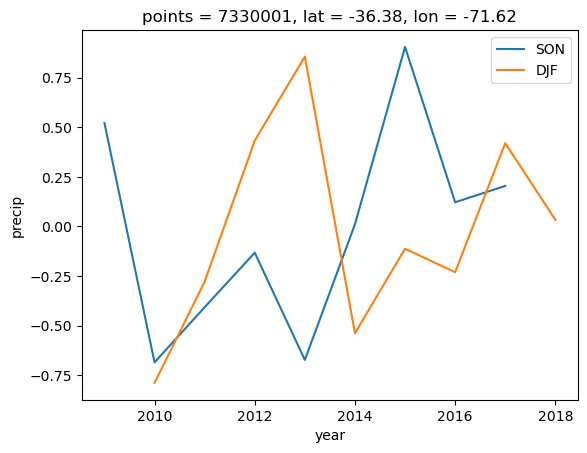

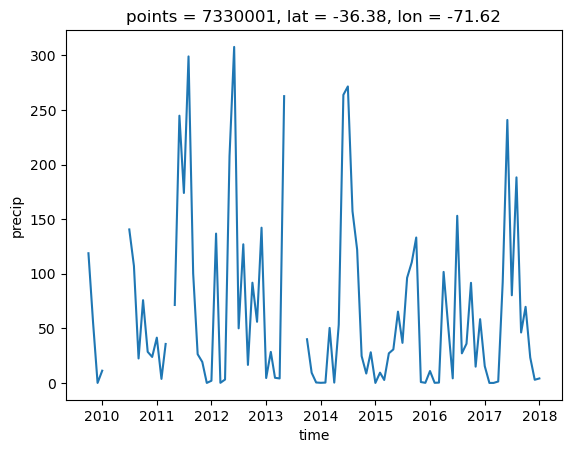

In [ ]:
##SON data

obs_precip_SON=var_prepper(obs_precip_sel, [9,10,11])
obs_precip_DJF=var_prepper(obs_precip_sel, [12,1,2])

obs_temp_SON=var_prepper(obs_temp_sel, [9,10,11])
obs_temp_DJF=var_prepper(obs_temp_sel, [12,1,2])

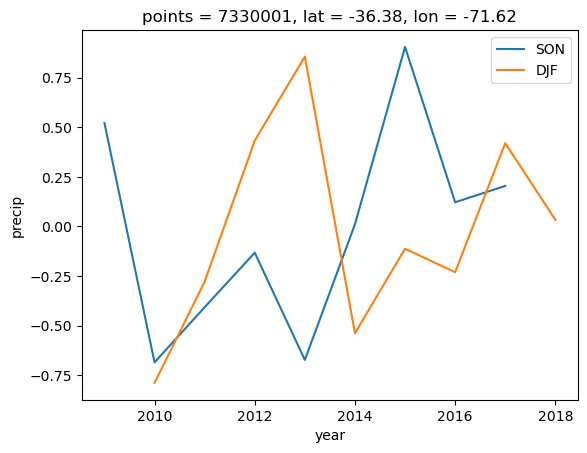

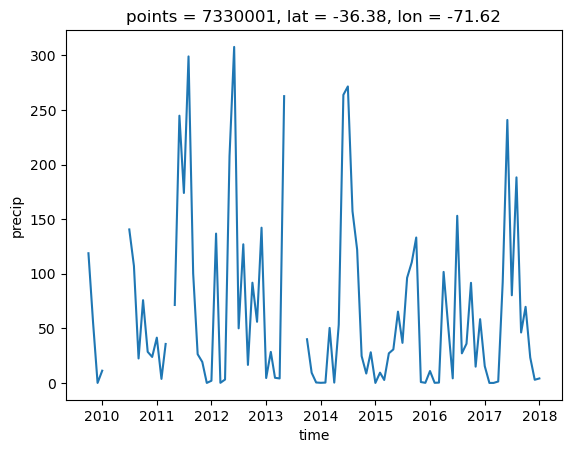

In [15]:
##sanity check for data
p=498
a=obs_precip_SON.isel(points=p)
b=obs_precip_DJF.isel(points=p)
a['precip'].plot(label='SON')
b['precip'].plot(label='DJF')
plt.legend()
plt.show()
obs_precip_sel.isel(points=p)['precip'].plot()
plt.show()


In [ ]:
import plotly.express as px

df = px.data.gapminder().query("year == 2007")
fig = px.scatter_geo(df, locations="iso_alpha",
                     size="pop", # size of markers, "pop" is one of the columns of gapminder
                     )
fig.show()